In [ ]:
import seaborn as sns

# Load the Titanic dataset
titanic_df = sns.load_dataset('titanic')

# Display the first 5 rows of the dataset
display(titanic_df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Data Preprocessing for SVM

Before training the SVM model, we need to preprocess the data. This involves handling missing values, converting categorical features into numerical representations, and selecting relevant features.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Make a copy to avoid modifying the original dataframe
df = titanic_df.copy()

# Drop columns with too many missing values or irrelevant for the model
df = df.drop(columns=['deck', 'embark_town', 'who', 'alive', 'alone'])

# Handle missing 'Age' values by filling with the median
df['age'] = df['age'].fillna(df['age'].median())

# Handle missing 'Embarked' values by filling with the most frequent value (mode)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Display info to check for remaining missing values and data types
print("DataFrame Info after initial cleaning:")
df.info()

DataFrame Info after initial cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    object  
 3   age         891 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    891 non-null    object  
 8   class       891 non-null    category
 9   adult_male  891 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(4), object(2)
memory usage: 57.7+ KB


In [ ]:
# Define categorical and numerical features
categorical_features = ['sex', 'embarked', 'class']
numerical_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']

# Define the target variable (y) and features (X)
X = df[numerical_features + categorical_features]
y = df['survived']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Display the first few rows of the preprocessed features to verify
print("First 5 rows of features (before one-hot encoding, after some drops and fillna):")
display(X.head())

First 5 rows of features (before one-hot encoding, after some drops and fillna):


,pclass,age,sibsp,parch,fare,sex,embarked,class
0,3,22.0,1,0,7.2500,male,S,Third
1,1,38.0,1,0,71.2833,female,C,First
2,3,26.0,0,0,7.9250,female,S,Third
3,1,35.0,1,0,53.1000,female,S,First
4,3,35.0,0,0,8.0500,male,S,Third


In [ ]:
# Following user's request, train_test_split is removed.
# The model will now be trained and evaluated on the entire dataset.
# Assign full dataset to X_train, y_train for pipeline consistency.
X_train, y_train = X, y

print(f"Training set shape (full dataset): {X_train.shape}")

Training set shape (full dataset): (891, 8)


In [ ]:
# Create the SVM pipeline
# We use 'SVC' for classification tasks
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# Train the SVM model
print("Training SVM model...")
svm_model.fit(X_train, y_train)
print("SVM model training complete.")

Training SVM model...
SVM model training complete.


Model Accuracy (on full dataset): 0.8384

Classification Report (on full dataset):
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       549
           1       0.84      0.71      0.77       342

    accuracy                           0.84       891
   macro avg       0.84      0.81      0.82       891
weighted avg       0.84      0.84      0.84       891



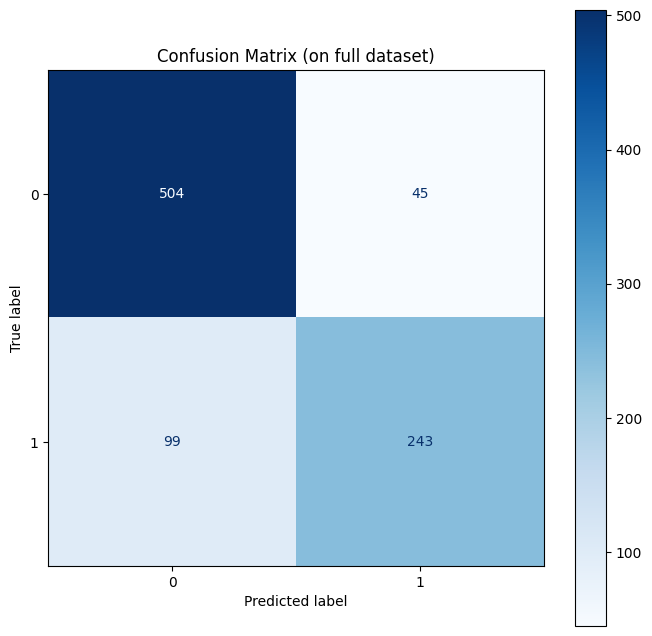

In [ ]:
# Make predictions on the entire dataset (as per user's request to remove train/test split)
y_pred = svm_model.predict(X)

# Evaluate the model on the entire dataset
accuracy = accuracy_score(y, y_pred) # Evaluate against y, not y_test
report = classification_report(y, y_pred) # Evaluate against y, not y_test

print(f"Model Accuracy (on full dataset): {accuracy:.4f}")
print("\nClassification Report (on full dataset):")
print(report)

# Visualize the confusion matrix on the full dataset
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(svm_model, X, y, cmap=plt.cm.Blues, ax=ax) # Use X and y
ax.set_title("Confusion Matrix (on full dataset)")
plt.show()

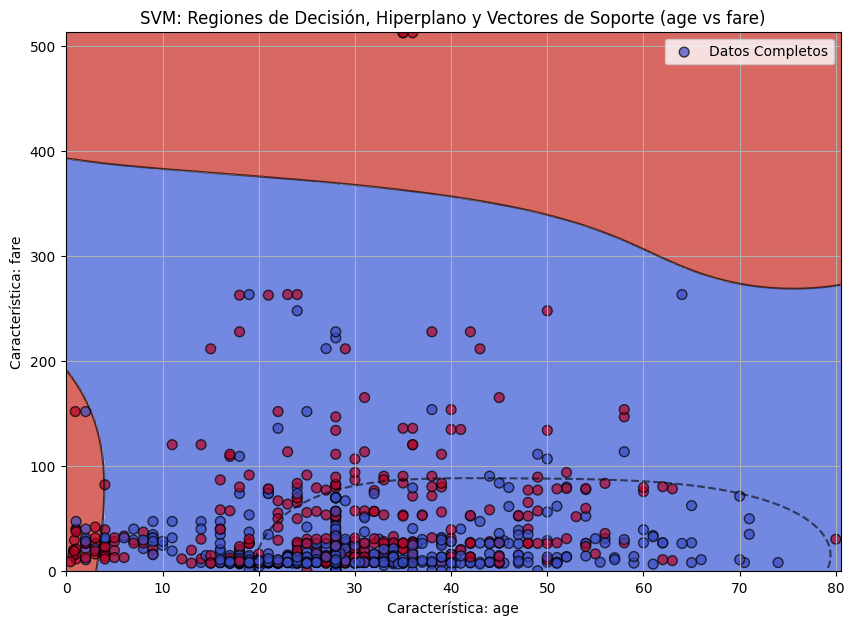

In [12]:
import pandas as pd

# Changed to continuous features for better decision boundary visualization
feature1_idx = 1 # 'age'
feature2_idx = 4 # 'fare'

# Use X_train (the original DataFrame) for column names
feature1_name = X_train.columns[feature1_idx]
feature2_name = X_train.columns[feature2_idx]

# X_train is a DataFrame, use .iloc for numerical indexing
x_min, x_max = X_train.iloc[:, feature1_idx].min() - 0.5, X_train.iloc[:, feature1_idx].max() + 0.5
y_min, y_max = X_train.iloc[:, feature2_idx].min() - 0.5, X_train.iloc[:, feature2_idx].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Create a template row from X_train, representing the "average" or "mode" of other features
# This is necessary because svm_model is a pipeline that expects all features
template_row = pd.DataFrame(columns=X_train.columns)
for col in X_train.columns:
    if col == feature1_name or col == feature2_name:
        template_row[col] = [0] # Placeholder, will be overwritten
    elif X_train[col].dtype in ['int64', 'float64']:
        template_row[col] = [X_train[col].mean()]
    else: # Categorical features: fill with mode
        template_row[col] = [X_train[col].mode()[0]]

# Expand the template row to the size of the meshgrid
X_mesh_df = pd.concat([template_row] * xx.ravel().shape[0], ignore_index=True)

# Assign the meshgrid values to the selected features
X_mesh_df[feature1_name] = xx.ravel()
X_mesh_df[feature2_name] = yy.ravel()

# Predict using the full pipeline, which handles preprocessing internally
Z = svm_model.predict(X_mesh_df)
Z = Z.reshape(xx.shape)

P = svm_model.decision_function(X_mesh_df)
P = P.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

plt.contour(xx, yy, P, colors='k', levels=[-1, 0, 1], alpha=0.6,
           linestyles=['--', '-', '--'])

# Use X and y for the scatter plot, as X_test/y_test are not defined after removing train_test_split
plt.scatter(X.iloc[:, feature1_idx], X.iloc[:, feature2_idx],
            c=y, edgecolors='k', cmap=plt.cm.coolwarm, label="Datos Completos", s=50, alpha=0.7)

# Removed support vector plotting as they are in the transformed feature space
# and plotting them directly on original feature axes would be incorrect without inverse transformation.

plt.xlabel(f'Característica: {feature1_name}')
plt.ylabel(f'Característica: {feature2_name}')
plt.title(f'SVM: Regiones de Decisión, Hiperplano y Vectores de Soporte ({feature1_name} vs {feature2_name})')
plt.legend()
plt.grid(True)
plt.show()